In [1]:
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Style cho đẹp
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Visualization libraries imported!")

Visualization libraries imported!


# Load dataset

In [3]:
# Load dataset mới
ds = load_dataset("ncduy/mt-en-vi")
print("Original size:", len(ds["train"]))

# Shuffle để random
ds["train"] = ds["train"].shuffle(seed=42)

# Lọc câu quá dài hoặc quá ngắn
def filter_fn(example):
    en_len = len(example["en"].split())
    vi_len = len(example["vi"].split())
    return 5 <= en_len <= 100 and 5 <= vi_len <= 100

ds["train"] = ds["train"].filter(filter_fn)
print(f"After filtering: {len(ds['train'])}")

# Chọn 300K samples
ds["train"] = ds["train"].select(range(min(500000, len(ds["train"]))))
print(f"Final size: {len(ds['train'])}")


Original size: 2884451
After filtering: 2733054
Final size: 500000


In [4]:
train_data = ds["train"]

print("Dataset splits:", ds)
print("Number of training pairs:", len(train_data))

Dataset splits: DatasetDict({
    train: Dataset({
        features: ['en', 'vi', 'source'],
        num_rows: 500000
    })
    validation: Dataset({
        features: ['en', 'vi', 'source'],
        num_rows: 11316
    })
    test: Dataset({
        features: ['en', 'vi', 'source'],
        num_rows: 11225
    })
})
Number of training pairs: 500000


In [5]:
for i in range(5):
    en = train_data[i]["en"]
    vi = train_data[i]["vi"]

    print(f"[{i}] EN: {en}")
    print(f"    VI: {vi}\n")


[0] EN: "education and leading me to providing service to the Republic."
    VI: "nơi giáo dục và dìu dắt tôi để tôi có thể phụng sự nền Cộng Hòa"

[1] EN: Because of the big, bad Fizzle Bomber?
    VI: Có phải vì Kẻ Ném Bom Xì Xèo xấu xa?

[2] EN: The author of numerous collections of poems, short stories, young adult novels, and seven novels, Mars is one of the most active contemporary Haitian writers.
    VI: Là tác giả của nhiều bộ sưu tập thơ, truyện ngắn, tiểu thuyết người lớn trẻ tuổi và bảy tiểu thuyết, Mars là một trong những nhà văn Haiti đương đại hoạt động tích cực nhất.

[3] EN: R's are less than one, no spread of the disease;
    VI: R nhỏ hơn một, không có sự lây truyền bệnh.

[4] EN: Well, I'm oversexed... I mean...
    VI: À, tôi khát tình... ý tôi là...



In [6]:
total_pairs = len(train_data)
print("Tổng số cặp câu:", total_pairs)


Tổng số cặp câu: 500000


In [7]:
en_lengths = [len(x["en"].split()) for x in train_data]
vi_lengths = [len(x["vi"].split()) for x in train_data]

print(" Độ dài câu trung bình:")
print("   EN:", np.mean(en_lengths))
print("   VI:", np.mean(vi_lengths))


 Độ dài câu trung bình:
   EN: 14.309024
   VI: 18.519632


In [8]:
empty_count = 0
examples = []

for i, item in enumerate(train_data):
    en = item["en"]
    vi = item["vi"]

    if en is None or vi is None or en.strip() == "" or vi.strip() == "":
        empty_count += 1
        if len(examples) < 3:
            examples.append((i, en, vi))

print("\n Số cặp câu rỗng / lỗi:", empty_count)

if examples:
    print("\nVí dụ lỗi:")
    for idx, en, vi in examples:
        print(f"[{idx}] EN: {en} | VI: {vi}")



 Số cặp câu rỗng / lỗi: 0


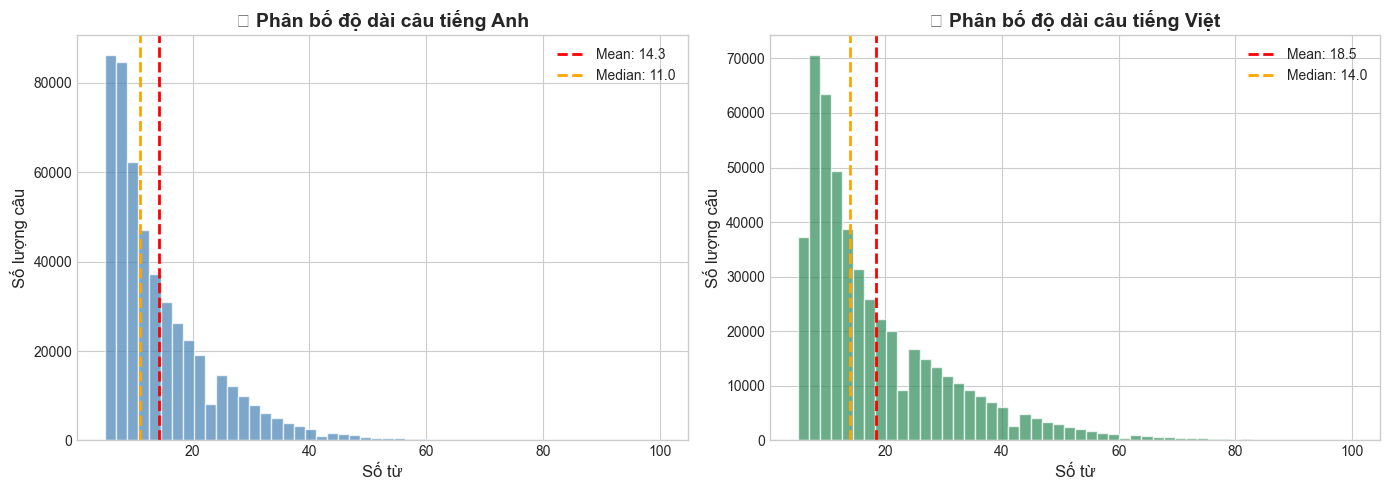


📈 Thống kê độ dài câu:
   English - Mean: 14.3, Median: 11.0, Std: 9.5
   Vietnamese - Mean: 18.5, Median: 14.0, Std: 13.1


In [9]:
# HISTOGRAM - Phân bố độ dài câu
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# English
axes[0].hist(en_lengths, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(np.mean(en_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(en_lengths):.1f}')
axes[0].axvline(np.median(en_lengths), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(en_lengths):.1f}')
axes[0].set_xlabel('Số từ', fontsize=12)
axes[0].set_ylabel('Số lượng câu', fontsize=12)
axes[0].set_title('📊 Phân bố độ dài câu tiếng Anh', fontsize=14, fontweight='bold')
axes[0].legend()

# Vietnamese
axes[1].hist(vi_lengths, bins=50, color='seagreen', edgecolor='white', alpha=0.7)
axes[1].axvline(np.mean(vi_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(vi_lengths):.1f}')
axes[1].axvline(np.median(vi_lengths), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(vi_lengths):.1f}')
axes[1].set_xlabel('Số từ', fontsize=12)
axes[1].set_ylabel('Số lượng câu', fontsize=12)
axes[1].set_title('📊 Phân bố độ dài câu tiếng Việt', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('sentence_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📈 Thống kê độ dài câu:")
print(f"   English - Mean: {np.mean(en_lengths):.1f}, Median: {np.median(en_lengths):.1f}, Std: {np.std(en_lengths):.1f}")
print(f"   Vietnamese - Mean: {np.mean(vi_lengths):.1f}, Median: {np.median(vi_lengths):.1f}, Std: {np.std(vi_lengths):.1f}")

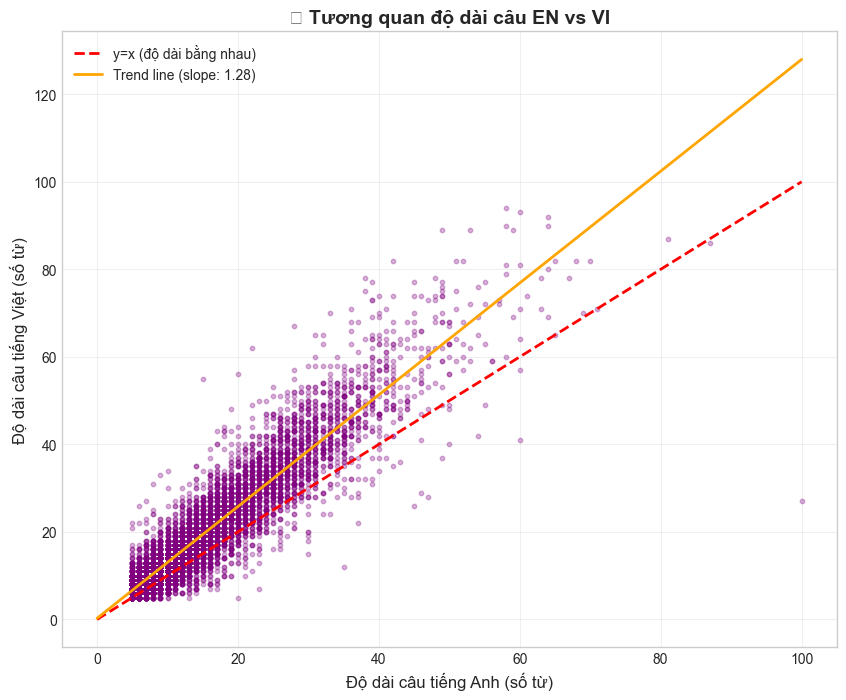


📊 Hệ số tương quan (Correlation): 0.9285
   → Độ dài câu EN và VI có tương quan mạnh


In [10]:
# SCATTER PLOT - So sánh độ dài EN vs VI
# Lấy sample để plot nhanh hơn
sample_size = min(10000, len(en_lengths))
indices = np.random.choice(len(en_lengths), sample_size, replace=False)

en_sample = [en_lengths[i] for i in indices]
vi_sample = [vi_lengths[i] for i in indices]

plt.figure(figsize=(10, 8))
plt.scatter(en_sample, vi_sample, alpha=0.3, s=10, c='purple')
plt.plot([0, max(en_sample)], [0, max(en_sample)], 'r--', linewidth=2, label='y=x (độ dài bằng nhau)')

# Regression line
z = np.polyfit(en_sample, vi_sample, 1)
p = np.poly1d(z)
x_line = np.linspace(0, max(en_sample), 100)
plt.plot(x_line, p(x_line), 'orange', linewidth=2, label=f'Trend line (slope: {z[0]:.2f})')

plt.xlabel('Độ dài câu tiếng Anh (số từ)', fontsize=12)
plt.ylabel('Độ dài câu tiếng Việt (số từ)', fontsize=12)
plt.title('📊 Tương quan độ dài câu EN vs VI', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('en_vi_length_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Tính correlation
correlation = np.corrcoef(en_lengths, vi_lengths)[0, 1]
print(f"\n📊 Hệ số tương quan (Correlation): {correlation:.4f}")
print(f"   → Độ dài câu EN và VI có tương quan {'mạnh' if correlation > 0.7 else 'trung bình' if correlation > 0.5 else 'yếu'}")

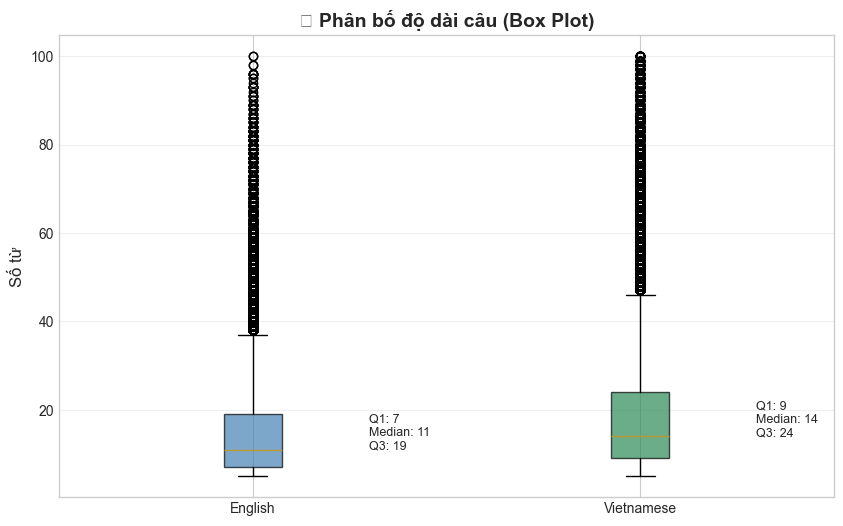

In [11]:
# BOX PLOT - So sánh phân bố độ dài
fig, ax = plt.subplots(figsize=(10, 6))

data_to_plot = [en_lengths, vi_lengths]
bp = ax.boxplot(data_to_plot, patch_artist=True, labels=['English', 'Vietnamese'])

colors = ['steelblue', 'seagreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Số từ', fontsize=12)
ax.set_title('📊 Phân bố độ dài câu (Box Plot)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Thêm statistics
for i, (data, label) in enumerate(zip(data_to_plot, ['EN', 'VI'])):
    q1, median, q3 = np.percentile(data, [25, 50, 75])
    ax.annotate(f'Q1: {q1:.0f}\nMedian: {median:.0f}\nQ3: {q3:.0f}', 
                xy=(i + 1.3, median), fontsize=9, ha='left')

plt.savefig('boxplot_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

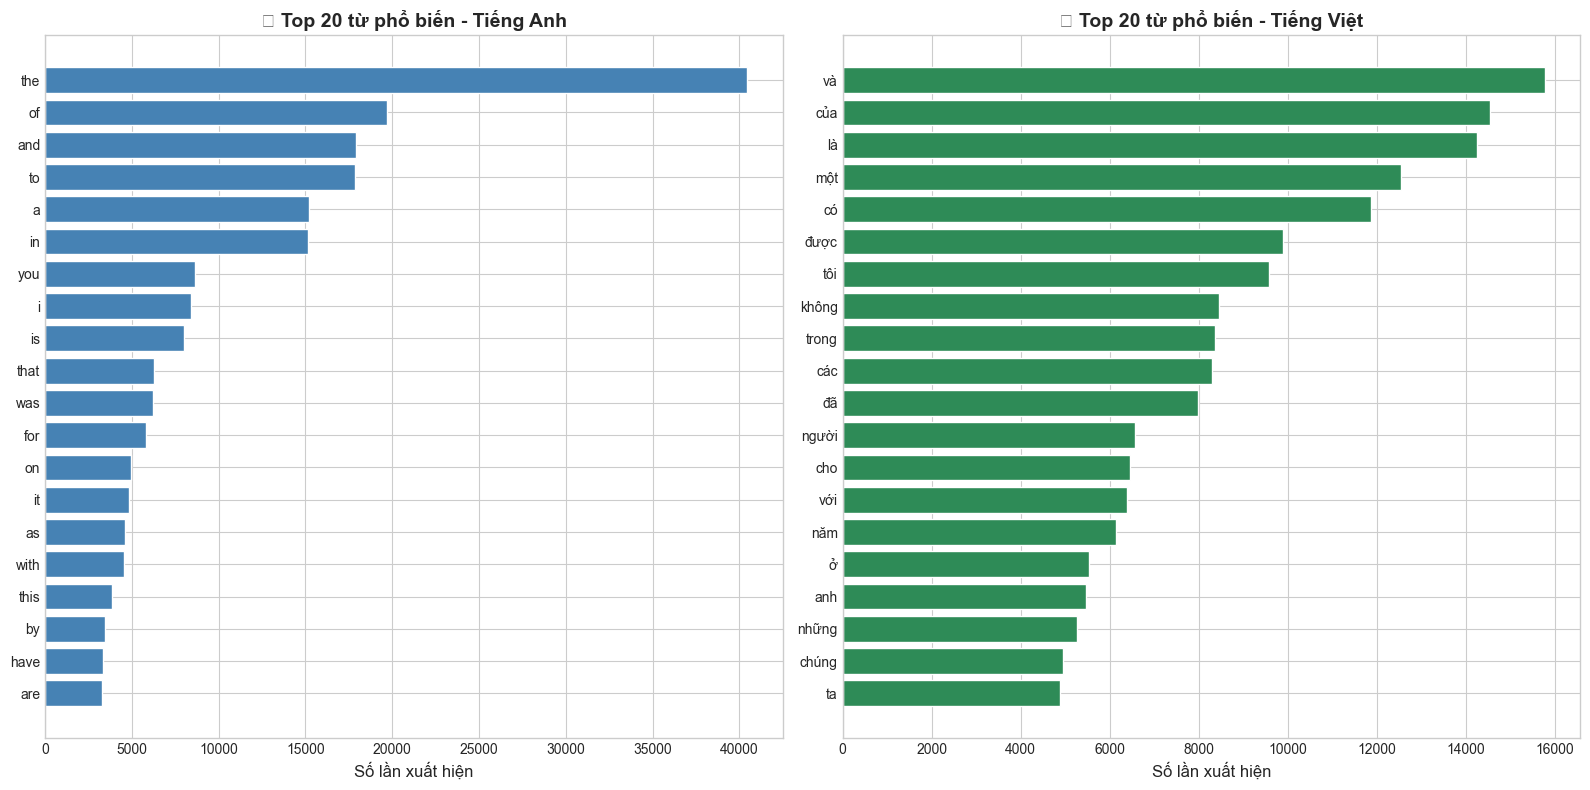

In [12]:
# TOP 20 TỪ PHỔ BIẾN NHẤT
def get_top_words(texts, n=20, language='en'):
    """Lấy top n từ phổ biến nhất"""
    all_words = []
    for text in texts:
        words = text.lower().split()
        all_words.extend(words)
    return Counter(all_words).most_common(n)

# Sample để nhanh hơn
sample_texts_en = [train_data[i]['en'] for i in range(min(50000, len(train_data)))]
sample_texts_vi = [train_data[i]['vi'] for i in range(min(50000, len(train_data)))]

top_en = get_top_words(sample_texts_en, 20)
top_vi = get_top_words(sample_texts_vi, 20)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# English
words_en = [w[0] for w in top_en]
counts_en = [w[1] for w in top_en]
axes[0].barh(words_en[::-1], counts_en[::-1], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Số lần xuất hiện', fontsize=12)
axes[0].set_title('📊 Top 20 từ phổ biến - Tiếng Anh', fontsize=14, fontweight='bold')

# Vietnamese
words_vi = [w[0] for w in top_vi]
counts_vi = [w[1] for w in top_vi]
axes[1].barh(words_vi[::-1], counts_vi[::-1], color='seagreen', edgecolor='white')
axes[1].set_xlabel('Số lần xuất hiện', fontsize=12)
axes[1].set_title('📊 Top 20 từ phổ biến - Tiếng Việt', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()


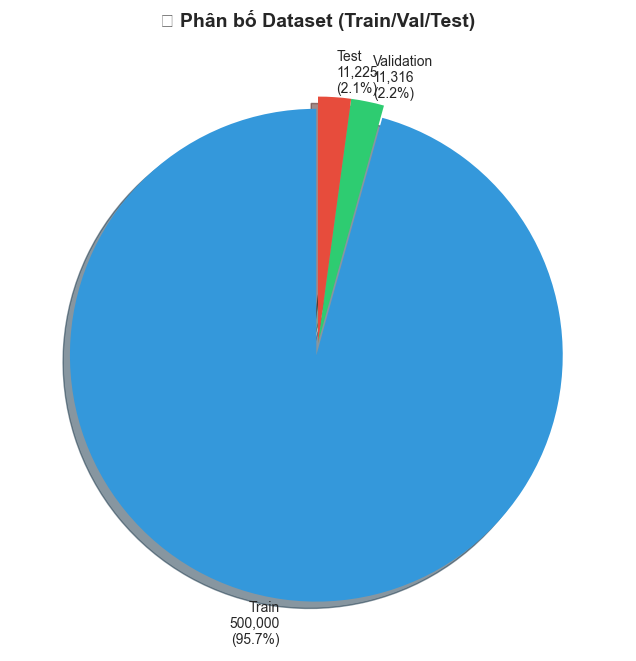


📊 Chi tiết phân chia dataset:
   Train:      500,000 samples (95.7%)
   Validation: 11,316 samples (2.2%)
   Test:       11,225 samples (2.1%)
   Total:      522,541 samples


In [13]:
# PIE CHART - Phân bố Train/Val/Test
fig, ax = plt.subplots(figsize=(8, 8))

sizes = [len(ds['train']), len(ds['validation']), len(ds['test'])]
labels = [f"Train\n{sizes[0]:,}\n({sizes[0]/sum(sizes)*100:.1f}%)", 
          f"Validation\n{sizes[1]:,}\n({sizes[1]/sum(sizes)*100:.1f}%)", 
          f"Test\n{sizes[2]:,}\n({sizes[2]/sum(sizes)*100:.1f}%)"]
colors = ['#3498db', '#2ecc71', '#e74c3c']
explode = (0.05, 0, 0)

wedges, texts, autotexts = ax.pie(sizes, explode=explode, labels=labels, colors=colors,
                                   autopct='', startangle=90, shadow=True)

ax.set_title('📊 Phân bố Dataset (Train/Val/Test)', fontsize=14, fontweight='bold')

plt.savefig('dataset_split_pie.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Chi tiết phân chia dataset:")
print(f"   Train:      {sizes[0]:,} samples ({sizes[0]/sum(sizes)*100:.1f}%)")
print(f"   Validation: {sizes[1]:,} samples ({sizes[1]/sum(sizes)*100:.1f}%)")
print(f"   Test:       {sizes[2]:,} samples ({sizes[2]/sum(sizes)*100:.1f}%)")
print(f"   Total:      {sum(sizes):,} samples")


In [14]:
#  DATA QUALITY SUMMARY
print("=" * 60)
print(" TỔNG KẾT DATASET")
print("=" * 60)

total = len(ds['train']) + len(ds['validation']) + len(ds['test'])

print(f"""
 Dataset: ncduy/mt-en-vi
 Domain: TED talks / General

├── Tổng số cặp câu: {total:,}
│
├── Train:      {len(ds['train']):,} ({len(ds['train'])/total*100:.1f}%)
├── Validation: {len(ds['validation']):,} ({len(ds['validation'])/total*100:.1f}%)
└── Test:       {len(ds['test']):,} ({len(ds['test'])/total*100:.1f}%)

 Thống kê độ dài:
├── EN: Mean={np.mean(en_lengths):.1f}, Median={np.median(en_lengths):.1f}, Std={np.std(en_lengths):.1f}
└── VI: Mean={np.mean(vi_lengths):.1f}, Median={np.median(vi_lengths):.1f}, Std={np.std(vi_lengths):.1f}

 Chất lượng: Đã lọc câu < 5 từ và > 100 từ
""")
print("=" * 60)


 TỔNG KẾT DATASET

 Dataset: ncduy/mt-en-vi
 Domain: TED talks / General

├── Tổng số cặp câu: 522,541
│
├── Train:      500,000 (95.7%)
├── Validation: 11,316 (2.2%)
└── Test:       11,225 (2.1%)

 Thống kê độ dài:
├── EN: Mean=14.3, Median=11.0, Std=9.5
└── VI: Mean=18.5, Median=14.0, Std=13.1

 Chất lượng: Đã lọc câu < 5 từ và > 100 từ



# Save dataset

In [15]:
ds.save_to_disk(r"C:\Users\FPT\Visual Studio code\KhiemPython\Machine Translation\split_dataset")
print("Đã lưu dataset")

Saving the dataset (0/1 shards):   0%|          | 0/500000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/11316 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/11225 [00:00<?, ? examples/s]

Đã lưu dataset


In [16]:
for i in range(3):
    print(f"EN: {ds['train'][i]['en'][:100]}...")
    print(f"VI: {ds['train'][i]['vi'][:100]}...")
    print("-"*50)

EN: "education and leading me to providing service to the Republic."...
VI: "nơi giáo dục và dìu dắt tôi để tôi có thể phụng sự nền Cộng Hòa"...
--------------------------------------------------
EN: Because of the big, bad Fizzle Bomber?...
VI: Có phải vì Kẻ Ném Bom Xì Xèo xấu xa?...
--------------------------------------------------
EN: The author of numerous collections of poems, short stories, young adult novels, and seven novels, Ma...
VI: Là tác giả của nhiều bộ sưu tập thơ, truyện ngắn, tiểu thuyết người lớn trẻ tuổi và bảy tiểu thuyết,...
--------------------------------------------------


# dataset pretokenized

In [17]:
from underthesea import word_tokenize
from datasets import load_from_disk

dataset = load_from_disk("./split_dataset")

def tokenize_vi(example):
    example["vi"] = word_tokenize(example["vi"], format="text")
    return example

print("Tokenizing Vietnamese...")
tokenized = dataset.map(tokenize_vi, desc="Tokenizing")

print("Saving...")
tokenized.save_to_disk("./split_dataset_tokenized")
print("✓ Done! Upload folder 'split_dataset_tokenized' lên Kaggle")


Tokenizing Vietnamese...


Tokenizing:   0%|          | 0/500000 [00:00<?, ? examples/s]

Saving...


Saving the dataset (0/1 shards):   0%|          | 0/500000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/11316 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/11225 [00:00<?, ? examples/s]

✓ Done! Upload folder 'split_dataset_tokenized' lên Kaggle
